# **Customer Churn Prediction**

#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
#No. of entries - 7043
#No. of null values in each column - 0
#18 columns have object(categorial) DType
#Memory Usage - 1.1+MB

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [12]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [13]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [14]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [15]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [16]:
df.shape

(7032, 21)

In [17]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [18]:
df.drop('customerID', axis=1, inplace=True)

In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [21]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


# Final Classification

# 🎯 Target

# Churn (Binary)

# 📈 Numerical

# tenure, MonthlyCharges, TotalCharges

# 📊 Categorical

# Binary: gender, SeniorCitizen, Partner, Dependents, PhoneService, PaperlessBilling, Churn
# Nominal: MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaymentMethod
# Ordinal: Contract

#**EDA(Exploratory Data Analysis)**

#Numerical


In [22]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Column: {column}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"Total Outliers : {len(outliers)}")
    print(f"Outlier Percentage : {(len(outliers)/len(df))*100:.2f}%")

    return outliers

<Axes: xlabel='tenure', ylabel='Count'>

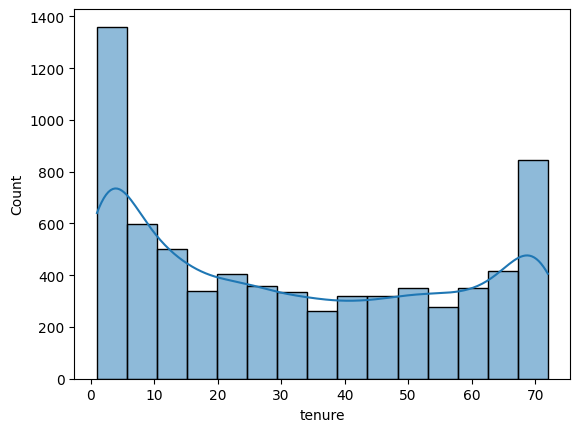

In [23]:
sns.histplot(df, x = 'tenure', kde = True)

<Axes: xlabel='tenure'>

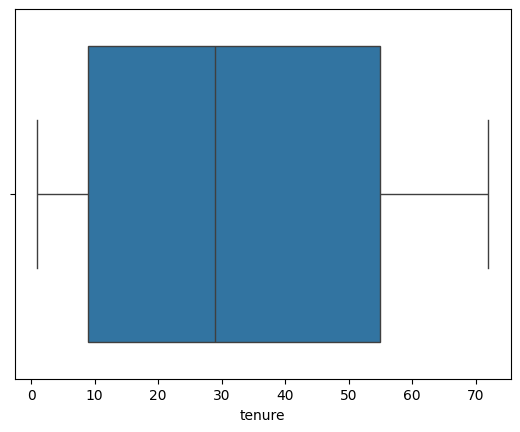

In [24]:
sns.boxplot(df, x = 'tenure')

In [25]:
df['tenure'].describe()

,tenure
count,7032.000000
mean,32.421786
std,24.545260
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [26]:
df['tenure'].skew()

np.float64(0.23773083190513133)

In [27]:
check_outliers(df, 'tenure')

Column: tenure
Lower Bound : -60.00
Upper Bound : 124.00
Total Outliers : 0
Outlier Percentage : 0.00%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#Tenure Feature Analysis
* Tenure is almost symmetric (Skewness = 0.23).
* No outliers are present.
* Mean and median are close to each other.
* Most customers are either new customers or long-term customers.
* If missing values were present, mean imputation would be acceptable because the distribution is nearly symmetric and there are no outliers.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

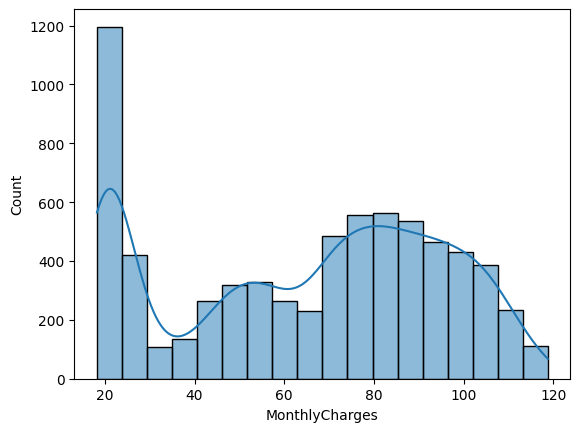

In [28]:
sns.histplot(df, x = 'MonthlyCharges' , kde = True)

<Axes: xlabel='MonthlyCharges'>

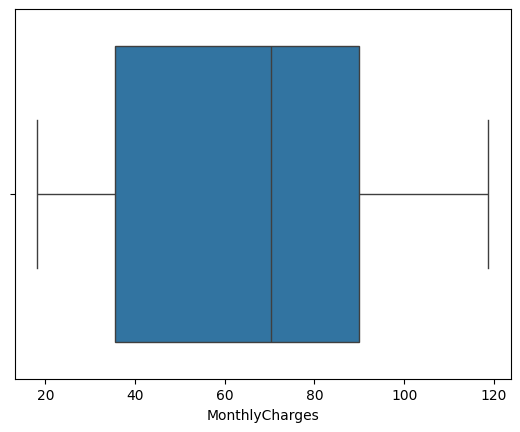

In [29]:
sns.boxplot(df, x = 'MonthlyCharges')

In [30]:
df['MonthlyCharges'].describe()

,MonthlyCharges
count,7032.000000
mean,64.798208
std,30.085974
min,18.250000
25%,35.587500
50%,70.350000
75%,89.862500
max,118.750000


In [31]:
df['MonthlyCharges'].skew()

np.float64(-0.22210292770166232)

In [32]:
check_outliers(df, 'MonthlyCharges')

Column: MonthlyCharges
Lower Bound : -45.82
Upper Bound : 171.27
Total Outliers : 0
Outlier Percentage : 0.00%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


# MonthlyCharges Feature Analysis

* MonthlyCharges is approximately symmetric (Skewness = -0.22).
* No outliers are present.
* Mean and median are close to each other.
* The distribution is bimodal, indicating two major groups of customers with different pricing plans.
* If missing values were present, mean imputation would be appropriate because the distribution is nearly symmetric and free from outliers.

<Axes: xlabel='TotalCharges', ylabel='Count'>

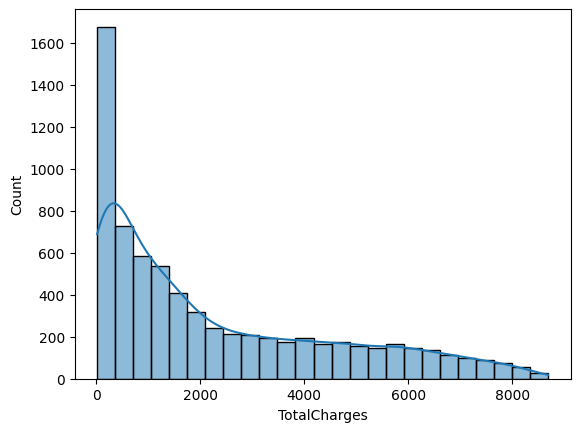

In [33]:
sns.histplot(df, x = 'TotalCharges', kde = True)

<Axes: xlabel='TotalCharges'>

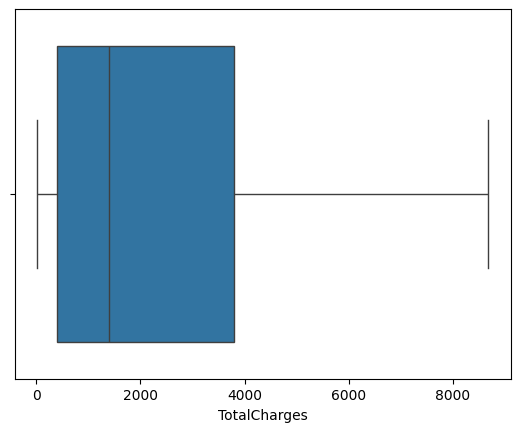

In [34]:
sns.boxplot(df, x = 'TotalCharges')

In [35]:
df['TotalCharges'].describe()

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


In [36]:
df['TotalCharges'].skew()

np.float64(0.9616424997242504)

In [37]:
check_outliers(df, 'TotalCharges')

Column: TotalCharges
Lower Bound : -4688.48
Upper Bound : 8884.67
Total Outliers : 0
Outlier Percentage : 0.00%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


# TotalCharges Feature Analysis

* TotalCharges is moderately right-skewed (Skewness = 0.96).
* Majority of customers have low TotalCharges, while a smaller number have very high TotalCharges.
* Mean is considerably higher than the median, indicating the influence of high-value customers.
* No outliers are detected using the boxplot.
* If missing values were present, median imputation would be preferred because the distribution is right-skewed.

#**Categorical**

# Univariate

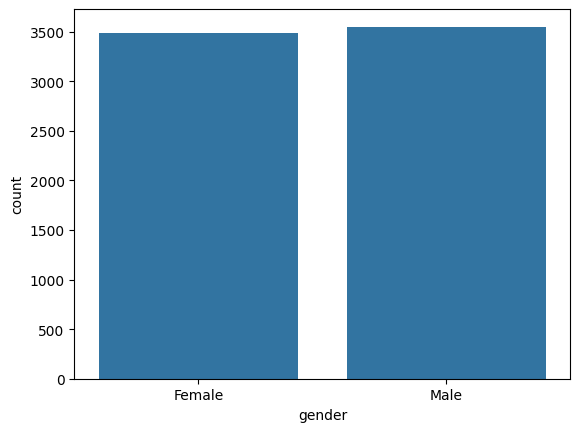

In [38]:
df['gender'].value_counts()

sns.countplot(data=df, x='gender')
plt.show()

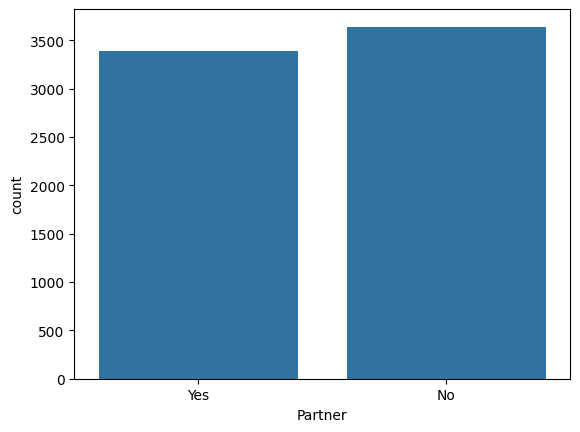

In [39]:
df['Partner'].value_counts()

sns.countplot(data=df, x='Partner')
plt.show()

gender
gender
Male      3549
Female    3483
Name: count, dtype: int64


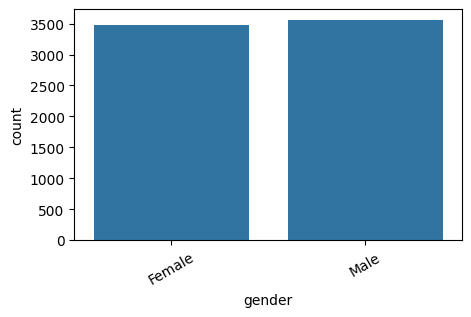

SeniorCitizen
SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64


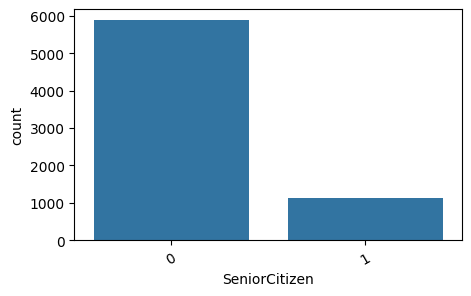

Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64


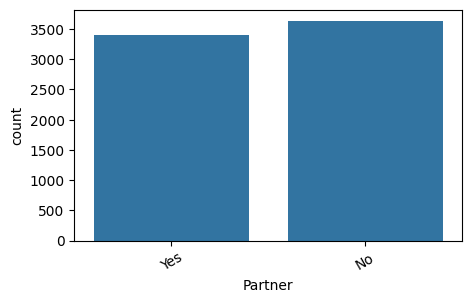

Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64


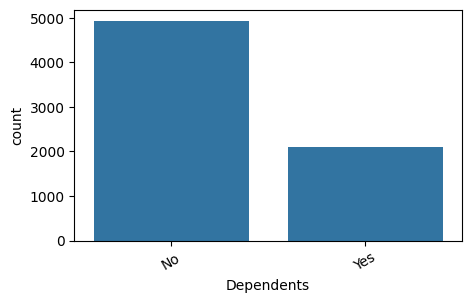

PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64


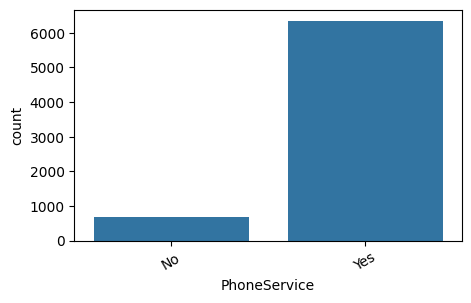

MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64


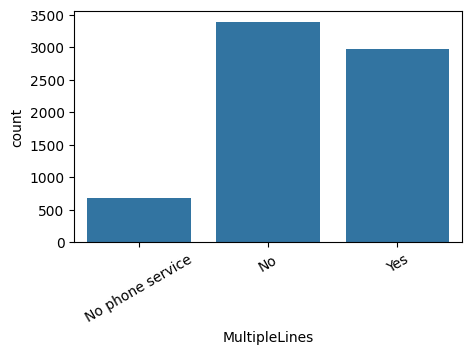

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64


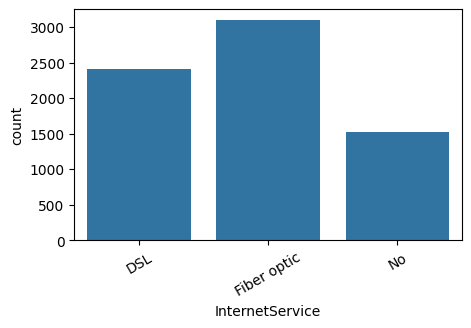

OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64


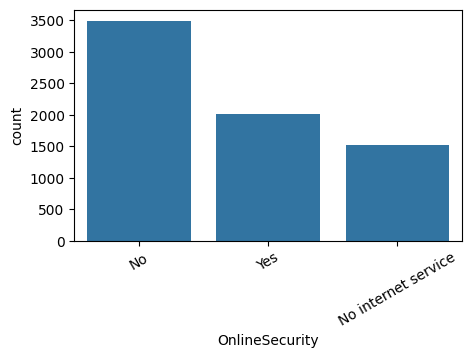

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64


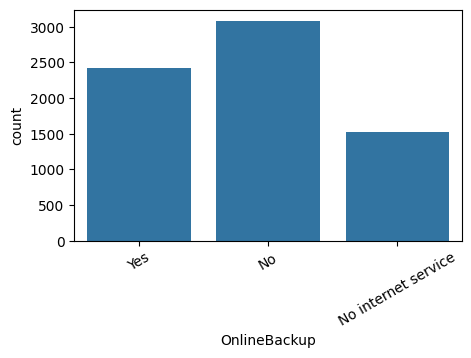

DeviceProtection
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64


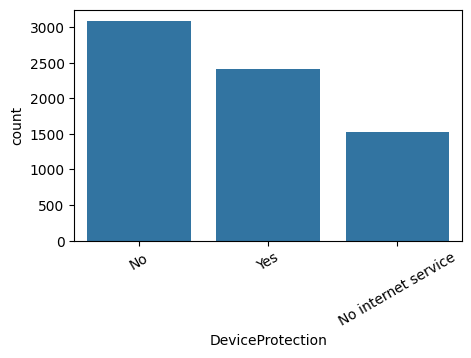

TechSupport
TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64


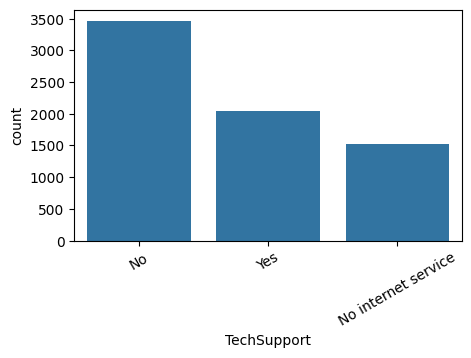

StreamingTV
StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64


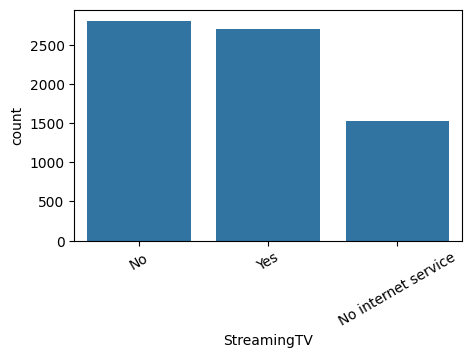

StreamingMovies
StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64


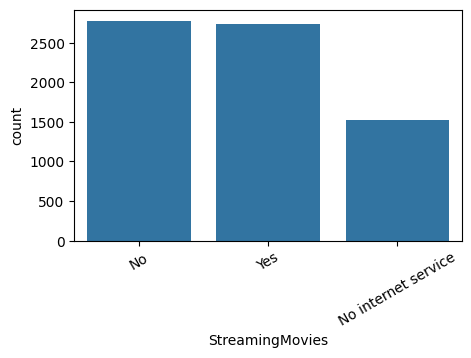

Contract
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


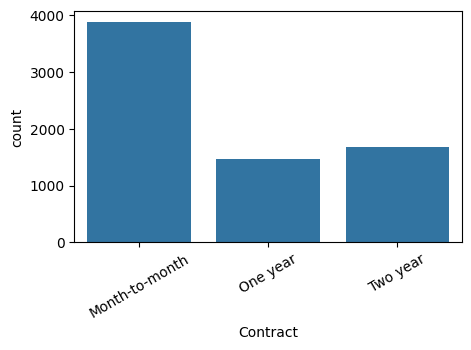

PaperlessBilling
PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64


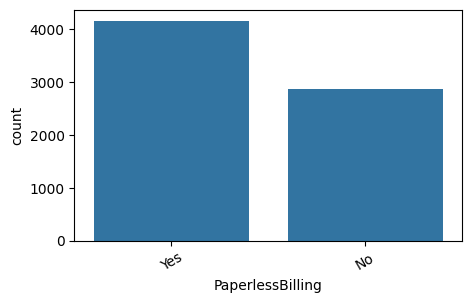

PaymentMethod
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64


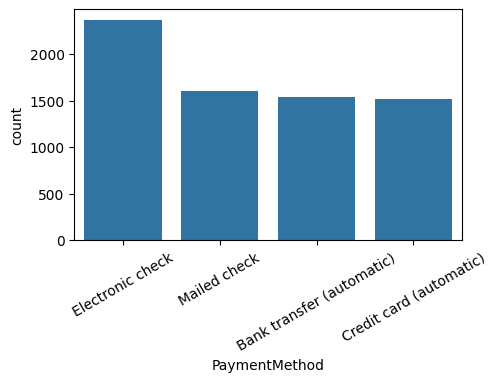

Churn
Churn
No     5163
Yes    1869
Name: count, dtype: int64


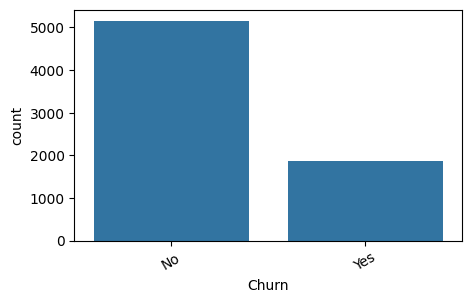

In [40]:
#Using loop for fast execution
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
    'Churn'
]

for col in categorical_cols:
    print("="*50)
    print(f"{col}")
    print(df[col].value_counts())

    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=30)
    plt.show()

# Gender
* Male and Female customers are almost equally distributed.

# SeniorCitizen
* Most customers are not senior citizens.

# Partner
* Customers with partners are slightly more than those without partners.

# Dependents
* Most customers do not have dependents.

# PhoneService
* Almost all customers have phone service.

# MultipleLines
* Most customers either have a single line or no multiple lines.

# InternetService
* Fiber optic and DSL are the most common internet services.
* A smaller number of customers have no internet service.

# OnlineSecurity
* Most customers do not subscribe to online security.

# OnlineBackup
* More customers do not have online backup than those who do.

# DeviceProtection
* Most customers have not subscribed to device protection.

# TechSupport
* Majority of customers do not have tech support.

# StreamingTV
* Customers are almost evenly distributed between having and not having streaming TV.

# StreamingMovies
* Similar distribution as StreamingTV.

# Contract
* Month-to-month contract customers are the highest.
* One-year and two-year contracts are comparatively fewer.

# PaperlessBilling
* Most customers prefer paperless billing.

# PaymentMethod
* Electronic check is the most commonly used payment method.

# Churn (Target)
* Most customers did not churn.
* The dataset is slightly imbalanced toward non-churn customers.

# Bivariate

gender vs Churn
Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565


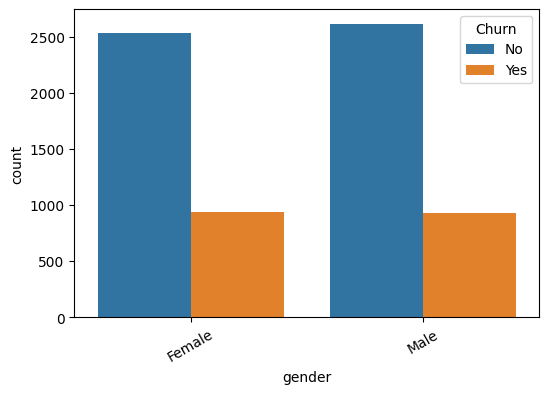

SeniorCitizen vs Churn
Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


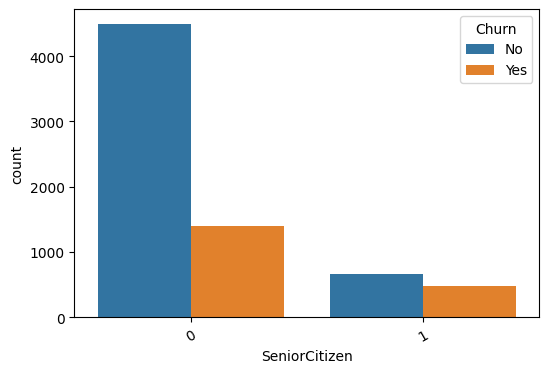

Partner vs Churn
Churn           No        Yes
Partner                      
No       67.023908  32.976092
Yes      80.282935  19.717065


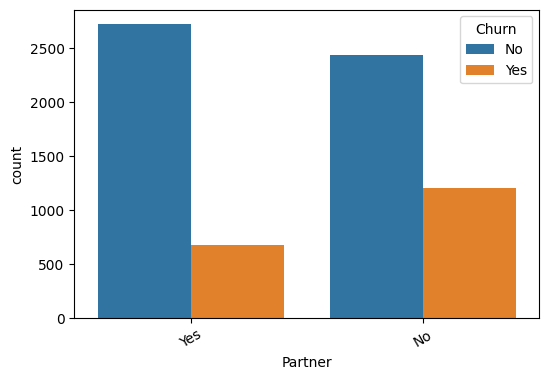

Dependents vs Churn
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205


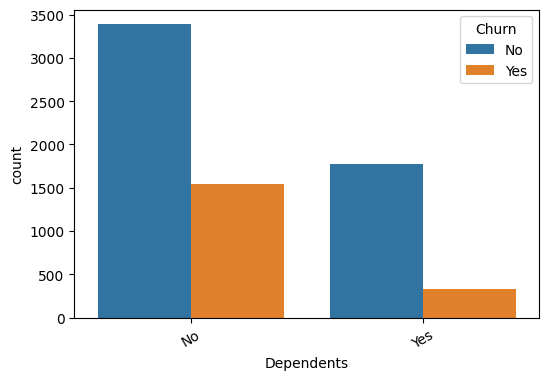

PhoneService vs Churn
Churn                No        Yes
PhoneService                      
No            75.000000  25.000000
Yes           73.252519  26.747481


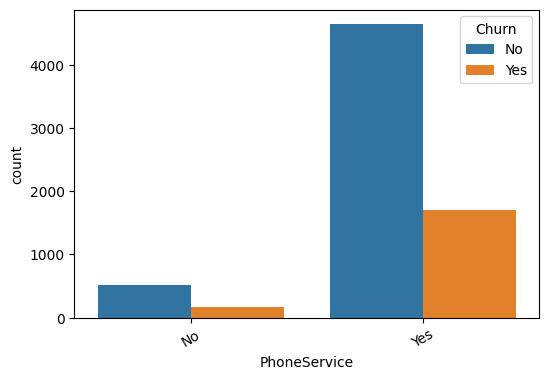

MultipleLines vs Churn
Churn                    No        Yes
MultipleLines                         
No                74.918759  25.081241
No phone service  75.000000  25.000000
Yes               71.351534  28.648466


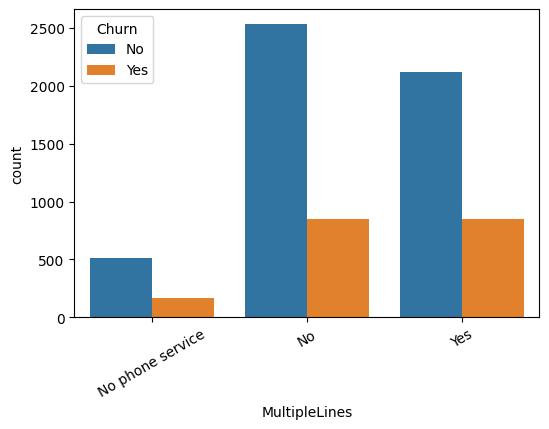

InternetService vs Churn
Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


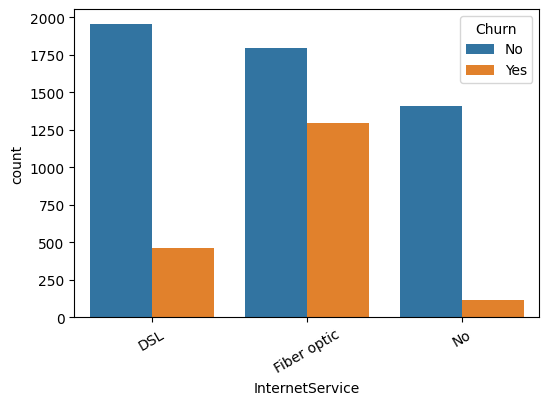

OnlineSecurity vs Churn
Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199


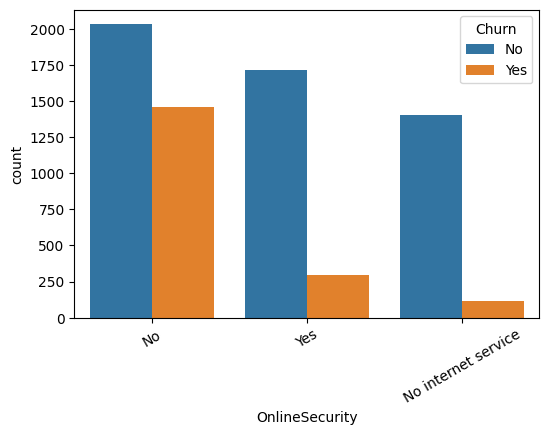

OnlineBackup vs Churn
Churn                       No        Yes
OnlineBackup                             
No                   60.058309  39.941691
No internet service  92.565789   7.434211
Yes                  78.432990  21.567010


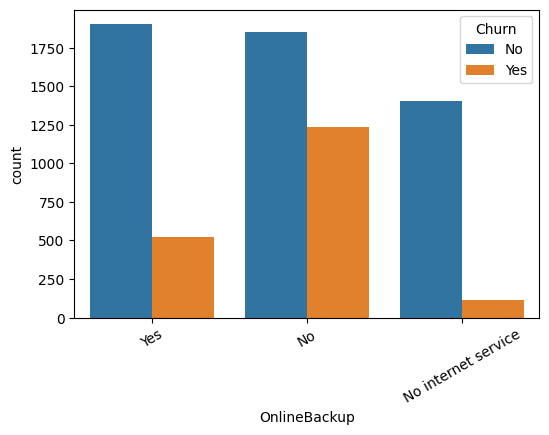

DeviceProtection vs Churn
Churn                       No        Yes
DeviceProtection                         
No                   60.859729  39.140271
No internet service  92.565789   7.434211
Yes                  77.460711  22.539289


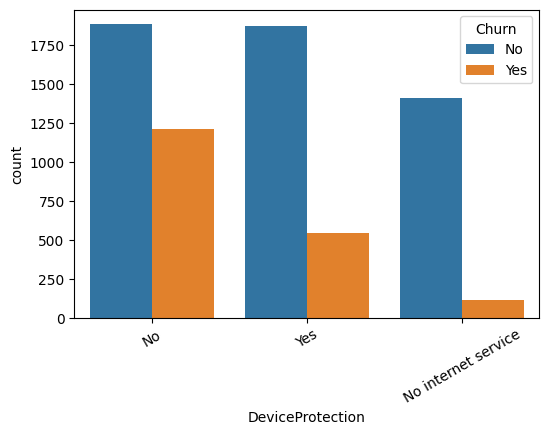

TechSupport vs Churn
Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


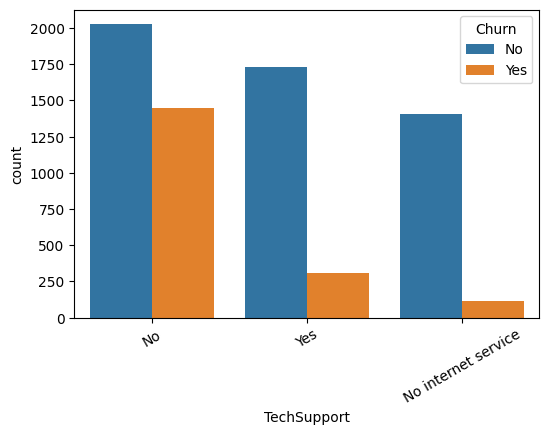

StreamingTV vs Churn
Churn                       No        Yes
StreamingTV                              
No                   66.464934  33.535066
No internet service  92.565789   7.434211
Yes                  69.885313  30.114687


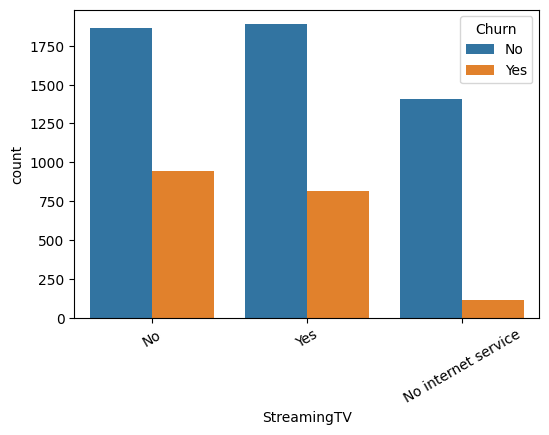

StreamingMovies vs Churn
Churn                       No        Yes
StreamingMovies                          
No                   66.271125  33.728875
No internet service  92.565789   7.434211
Yes                  70.047602  29.952398


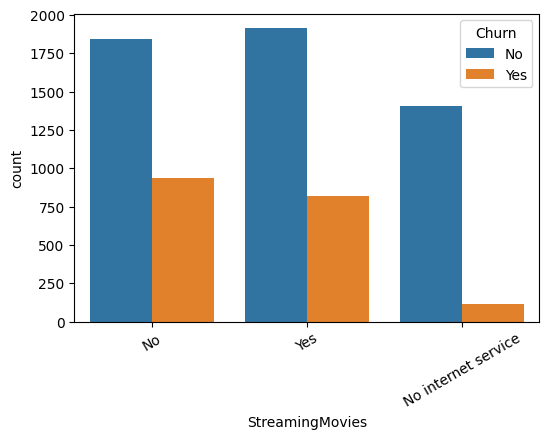

Contract vs Churn
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


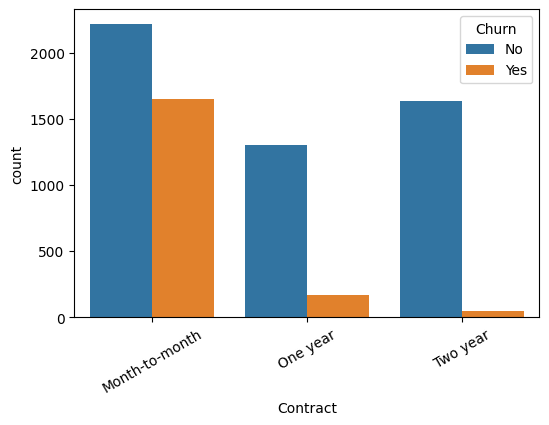

PaperlessBilling vs Churn
Churn                    No        Yes
PaperlessBilling                      
No                83.624302  16.375698
Yes               66.410749  33.589251


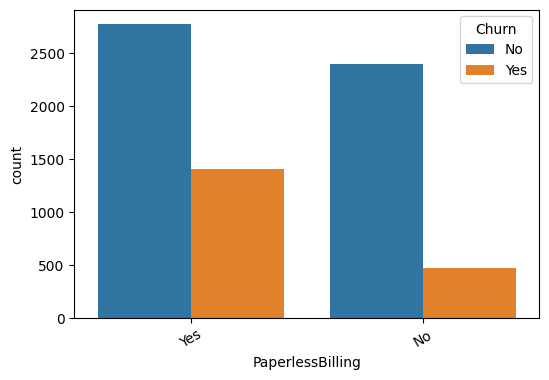

PaymentMethod vs Churn
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


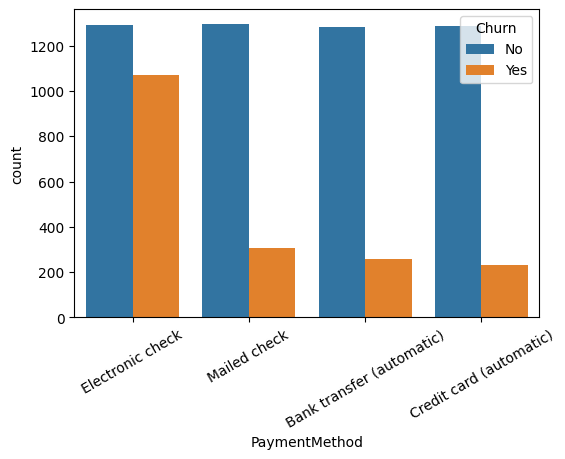

In [41]:
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for col in categorical_cols:
    print("="*60)
    print(f"{col} vs Churn")
    print(pd.crosstab(df[col], df['Churn'], normalize='index')*100)

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.xticks(rotation=30)
    plt.show()

### Gender vs Churn
* Male and female customers have a similar churn rate.
* Gender does not appear to have a strong impact on customer churn.
* I will keep this feature because it may still provide some predictive information.

### SeniorCitizen vs Churn
* Non-senior citizens have a higher number of churned customers because they represent the majority of customers.
* This feature will be kept.

### Partner vs Churn
* Customers without a partner have a higher churn rate than customers with a partner.
* This feature may influence churn prediction.

### Dependents vs Churn
* Customers without dependents have a higher churn rate.
* This feature will be kept.

### PhoneService vs Churn
* Customers with phone service have more churned customers, mainly because most customers use phone service.
* This feature will be kept.

### MultipleLines vs Churn
* Customers with single or multiple lines churn more than customers without phone service.
* This feature may be useful for prediction.

### InternetService vs Churn
* Customers using Fiber Optic internet have the highest churn rate.
* DSL customers have a lower churn rate.
* Customers with no internet service have the lowest churn rate.
* This is an important feature.

### OnlineSecurity vs Churn
* Customers without Online Security have a much higher churn rate.
* Customers with Online Security churn less.
* Customers without internet service show very low churn.
* This feature is important.

### OnlineBackup vs Churn
* Customers without Online Backup churn more than customers who have it.
* This feature will be kept.

### DeviceProtection vs Churn
* Customers without Device Protection have a higher churn rate.
* This feature may help in prediction.

### TechSupport vs Churn
* Customers without Tech Support churn significantly more.
* This is an important feature.

### StreamingTV vs Churn
* Customers with and without Streaming TV have a fairly similar churn pattern.
* This feature will still be kept.

### StreamingMovies vs Churn
* Similar trend as StreamingTV.
* This feature will be kept.

### Contract vs Churn
* Customers with Month-to-Month contracts have the highest churn rate.
* One-Year contract customers churn less.
* Two-Year contract customers have the lowest churn rate.
* This is one of the strongest features.

### PaperlessBilling vs Churn
* Customers using Paperless Billing have a higher churn rate.
* This feature will be kept.

### PaymentMethod vs Churn
* Electronic Check users have the highest churn rate.
* Other payment methods show comparatively lower churn.
* This feature appears to be important for churn prediction.

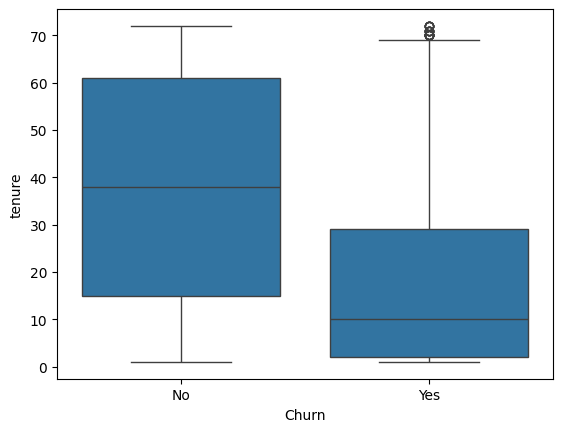

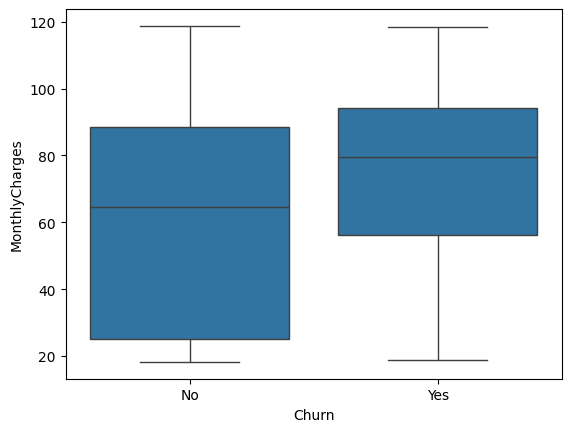

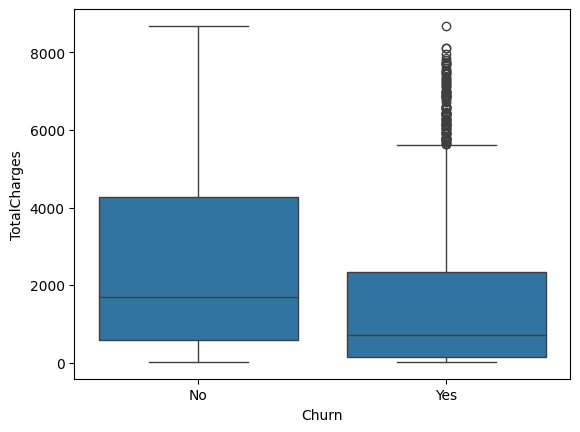

In [42]:
# Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure')
plt.show()

# Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.show()

# Total Charges vs Churn
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.show()

# Numerical Features vs Target Observations

### Tenure vs Churn
* Customers who did not churn generally have a higher tenure.
* Customers who churned usually have a lower tenure.
* A few high-tenure customers also churned, which appear as outliers.
* Tenure seems to be an important feature for predicting churn.

### MonthlyCharges vs Churn
* Customers who churned tend to have slightly higher monthly charges.
* The distributions overlap, but there is a noticeable difference in the median.
* Monthly Charges may contribute to churn prediction.

### TotalCharges vs Churn
* Customers who did not churn have higher total charges because they stayed with the company for a longer period.
* Customers who churned generally have lower total charges.
* Some high total charge customers also churned, resulting in outliers.
* Total Charges appears to be an important feature.

#**Encoding**

# Label Encoding

In [43]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

In [44]:
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']

for col in binary_cols:
    print(col, df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
PaperlessBilling ['Yes' 'No']


In [45]:
df['gender'] = df['gender'].map({'Female':0,'Male':1})
df['Partner'] = df['Partner'].map({'No':0,'Yes':1})
df['Dependents'] = df['Dependents'].map({'No':0,'Yes':1})
df['PhoneService'] = df['PhoneService'].map({'No':0,'Yes':1})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No':0,'Yes':1})


# One-Hot Encoding

In [46]:
nominal_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=nominal_cols, dtype=int)

In [47]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int64  
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   PaperlessBilling                         7032 non-null   int64  
 7   MonthlyCharges                           7032 non-null   float64
 8   TotalCharges                             7032 non-null   float64
 9   Churn                                    7032 non-null   int64  
 10  MultipleLines_No                         7032 non-nul

#**Correlation**

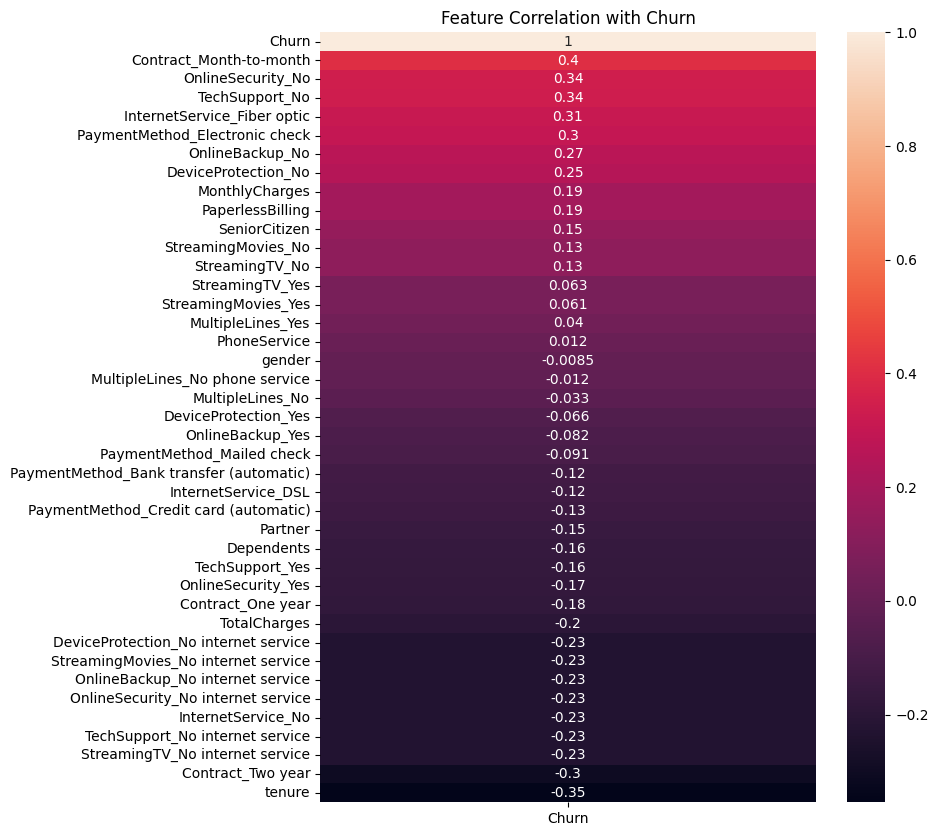

In [49]:
plt.figure(figsize=(8,10))
sns.heatmap(df.corr(numeric_only=True)[['Churn']].sort_values(by='Churn', ascending=False),
            annot=True)
plt.title("Feature Correlation with Churn")
plt.show()

#**Train Test Split**

In [50]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#**Feature Scaling**

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scaling Required

#**Logistic Regression**

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_LR = lr_model.predict(X_test_scaled)

accuracy_LR = accuracy_score(y_test, y_pred_LR)
print(f"Accuracy: {accuracy_LR:.2f}")

Accuracy: 0.79


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred_LR))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_LR))

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Confusion Matrix
[[914 119]
 [181 193]]


#**KNN (k-Nearest Neighbours)**

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

y_pred_KNN = knn_model.predict(X_test_scaled)

accuracy_KNN = accuracy_score(y_test, y_pred_KNN)
print(f"Accuracy: {accuracy_KNN:.2f}")

Accuracy: 0.76


In [56]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred_KNN))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_KNN))

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.54      0.54      0.54       374

    accuracy                           0.76      1407
   macro avg       0.69      0.69      0.69      1407
weighted avg       0.76      0.76      0.76      1407

Confusion Matrix
[[862 171]
 [173 201]]


#**SVM (Support Vector Machine)**

In [57]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_SVM = svm_model.predict(X_test_scaled)

accuracy_SVM = accuracy_score(y_test,y_pred_SVM)
print(f"Accuracy: {accuracy_SVM:.2f}")

Accuracy: 0.78


In [58]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred_SVM))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_SVM))

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1033
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

Confusion Matrix
[[924 109]
 [199 175]]


#Scaling Not Required

#**Decision Tree**

In [59]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_DT = dt_model.predict(X_test)

accuracy_DT = accuracy_score(y_test, y_pred_DT)
print(f"Accuracy: {accuracy_DT:.2f}")

Accuracy: 0.72


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred_DT))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_DT))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.48      0.49      0.48       374

    accuracy                           0.72      1407
   macro avg       0.64      0.65      0.65      1407
weighted avg       0.72      0.72      0.72      1407

Confusion Matrix
[[829 204]
 [189 185]]


#**Naive Bayes**

In [61]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_NB = nb_model.predict(X_test)

accuracy_NB = accuracy_score(y_test, y_pred_NB)
print(f"Accuracy: {accuracy_NB:.2f}")

Accuracy: 0.68


In [62]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred_NB))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_NB))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1033
           1       0.45      0.85      0.59       374

    accuracy                           0.68      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.68      0.70      1407

Confusion Matrix
[[641 392]
 [ 57 317]]


#**Random Forest**

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_RF = rf_model.predict(X_test)

accuracy_RF = accuracy_score(y_test, y_pred_RF)
print(f"Accuracy: {accuracy_RF:.2f}")


Accuracy: 0.79


In [64]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_test, y_pred_RF))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_RF))

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

Confusion Matrix
[[922 111]
 [191 183]]


In [65]:
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Decision Tree',
'Random Forest',
'KNN',
'SVM',
'Naive Bayes'
],

'Accuracy':[

accuracy_LR,
accuracy_DT,
accuracy_RF,
accuracy_KNN,
accuracy_SVM,
accuracy_NB

]

})

results.sort_values(
'Accuracy',
ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.786780
2,Random Forest,0.785359
4,SVM,0.781095
3,KNN,0.755508
1,Decision Tree,0.720682
5,Naive Bayes,0.680881


# Final Conclusion

* The objective of this project was to predict whether a customer will churn based on demographic, service usage, and billing information.

* During data preprocessing, missing values, incorrect data types, and unnecessary features were handled to prepare a clean dataset for model training.

* Exploratory Data Analysis (EDA) revealed that customers with month-to-month contracts, fiber optic internet, no online security, no tech support, and shorter tenure were more likely to churn.

* Numerical features such as Tenure, MonthlyCharges, and TotalCharges also showed meaningful relationships with the target variable.

* After encoding categorical variables and applying feature scaling where required, six machine learning algorithms were trained and evaluated.

# Model Performance

| Model | Accuracy |
|--------|----------|
| Logistic Regression | 78.68% |
| SVM | 78.11% |
| Random Forest | 77.68% |
| KNN | 75.55% |
| Decision Tree | 71.42% |
| Naive Bayes | 68.08% |

* Logistic Regression achieved the highest accuracy among all tested models, closely followed by SVM and Random Forest.

* Overall, this project demonstrates a complete end-to-end machine learning workflow, including data cleaning, exploratory data analysis, preprocessing, feature engineering through encoding, model building, and performance evaluation.